### Homework 2

Damion Huppert

In [7]:
using Pkg
Pkg.add("Plots")
using Plots
Pkg.add("JuMP")
using JuMP
Pkg.add("HiGHS")
using HiGHS
Pkg.add("DataFrames")
using DataFrames
Pkg.add("CSV")
using CSV
Pkg.add("NamedArrays")
using NamedArrays
Pkg.add("LinearAlgebra")
using LinearAlgebra
Pkg.add("XLSX")
using XLSX

   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No 

##### Question 1-1

Decision variables:  
- $x_1$ = Hours to run process 1  
- $x_2$ = Hours to run process 2  

Then a linear program that will minimize his cost will be:  

$$\min \quad 4x_1 + x_2$$  

Subject to:  

$$3x_1 + x_2 \geq 10  \quad \text{(Vial A constraint)}$$  
$$x_1 + x_2 \geq 5  \quad \text{(Vial B constraint)}$$  
$$x_1 \geq 3  \quad \text{(Vial C constraint)}$$  

$$x_1, x_2 \geq 0$$  


##### Question 1-2

In [8]:
m = Model(HiGHS.Optimizer)

@variable(m, x1 >= 0)
@variable(m, x2 >= 0)

@constraint(m, 3*x1 + x2 >= 10)
@constraint(m, x1 + x2 >= 5)
@constraint(m, x1 >= 3)

@objective(m, Min, 4*x1 + x2)

set_silent(m)
optimize!(m)

println("Termination status: ", termination_status(m))
println("optimal cost: \$", objective_value(m))
println("optimal hours to run process 1: ", value(x1))
println("optimal hours to run process 2: ", value(x2))


Termination status: OPTIMAL
optimal cost: $14.0
optimal hours to run process 1: 3.0
optimal hours to run process 2: 2.0


##### Question 1-3

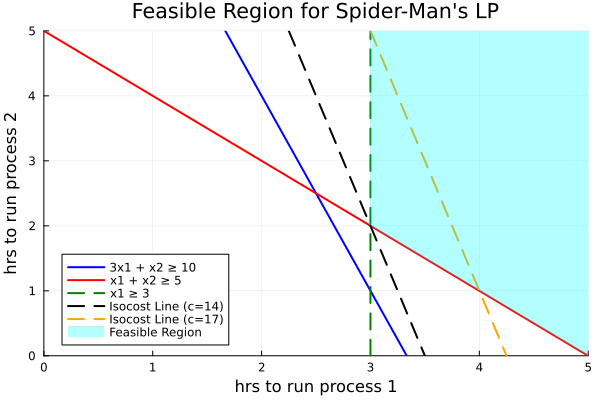

In [9]:
x1_range = 0:0.1:10
f1(x1) = 10 - 3*x1 
f2(x1) = 5 - x1
f3(x1) = 3

plot(x1_range, f1.(x1_range), label="3x1 + x2 ≥ 10", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="x1 + x2 ≥ 5", lw=2, color=:red)
plot!([3, 3], [0, 10], label="x1 ≥ 3", lw=2, color=:green, linestyle=:dash)

# isocost lines
isocost_line(x1) = c - 4*x1
c = 14
plot!(x1_range, isocost_line.(x1_range), label="Isocost Line (c=14)", linestyle=:dash, lw=2, color=:black)
c = 17
plot!(x1_range, isocost_line.(x1_range), label="Isocost Line (c=17)", linestyle=:dash, lw=2, color=:orange)

# feasiable region
x_vals = [3, 3, 5, 5, 3]
y_vals = [2, 5, 5, 0, 2]
plot!(x_vals, y_vals, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

xlabel!("hrs to run process 1")
ylabel!("hrs to run process 2")

title!("Feasible Region for Spider-Man's LP")

xlims!(0, 5)
ylims!(0, 5)


##### Questoin 1-4

Decision variables:  
- $x_j$ = Hours to run process $j$  

Then a linear program that will minimize cost will be:  

$$\min \quad \sum_{j \in J} c_jx_j$$  

Subject to:  

$$ \sum_{j \in J} a_{ij} x_j \geq b_i, \quad \forall i \in I$$
$$x_j \geq 0 \quad \forall j \in J$$  

where:  

$$ c_j: \text{Cost per hour of running process }  j , \forall j \in J $$
$$ a_{ij}: \text{ Number of vials of chemical i produced per hour by process j } \forall j \in J,\forall i \in I$$
$$ b_i: \text{Required vials of chemical \( i \) for snout fluid } \forall i \in I $$
$$ I: \text{Set of chemicals required for snout fluid } $$
$$ J: \text{Set of processes available to produce chemicals } $$



In [10]:
df = CSV.read("spider-man.csv", DataFrame, delim =',') 

# Processes are column names starting at the 3rd
J = propertynames(df)[3:end]

# Chemicals are the first column starting at the second row
I = convert(Array, df[2:end,1])

# Cost
c = Dict(zip(J,df[1,3:end]))

# Amt. required
b = Dict(zip(I,df[2:end,2]))

# Matrix of data 
A = Matrix(df[2:end,3:end])

# Make it a Named Array
A_NA = NamedArray(A, (I,J), ("Chemical", "Process")) 
;

In [11]:
m = Model(HiGHS.Optimizer)
@variable(m, x[J] >= 0)

@objective(m, Min, sum(c[j]*x[j] for j in J))

@constraint(m, [i in I], sum(A_NA[i,j]*x[j] for j in J) >= b[i])

# If you don't want the solver output, you can try this
set_silent(m)
optimize!(m)

println("Termination status: ", termination_status(m))

sol = Dict(j => value(x[j]) for j in J if value(x[j]) > 1.0e-6)
using Printf
@printf("\nMinimum cost is \$%.2f\n", objective_value(m))
# for (key, value) in sol
#   @printf("Run %s for %.2f hours\n", key, value)
# end

Termination status: OPTIMAL

Minimum cost is $1433.72


##### Question 2-1

In [12]:
m = Model(HiGHS.Optimizer)

@variable(m, x1 >= 0)
@variable(m, x2)
@variable(m, x3)
@variable(m, x4 >= 0)

@objective(m, Min, 2x1 - x2 + 3x3 - 2x4)

@constraint(m, 3x2 - x3 + 4x4 >= 10)
@constraint(m, 4x1 - 7x2 + x3 - x4 == 5)
@constraint(m, x1 - 3x3 + 8x4 <= 3)

optimize!(m)

println()
println("Model Termination Status: ", termination_status(m))
println("Optimal objective value: ", objective_value(m))
println("optimal x1: ", value(x1))
println("optimal x2: ", value(x2))
println("optimal x3: ", value(x3))
println("optimal x4: ", value(x4))


Running HiGHS 1.9.0 (git hash: 66f735e60): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 8e+00]
  Cost   [1e+00, 3e+00]
  Bound  [0e+00, 0e+00]
  RHS    [3e+00, 1e+01]
Presolving model
3 rows, 4 cols, 10 nonzeros  0s
2 rows, 3 cols, 6 nonzeros  0s
1 rows, 2 cols, 2 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-3); columns 0(-4); elements 0(-10) - Reduced to empty
Solving the original LP from the solution after postsolve
Model status        : Optimal
Objective value     :  1.5937500000e+01
Relative P-D gap    :  2.2291536808e-16
HiGHS run time      :          0.00

Model Termination Status: OPTIMAL
Optimal objective value: 15.937500000000004
optimal x1: 7.593750000000001
optimal x2: 3.84375
optimal x3: 1.5312500000000007
optimal x4: 0.0


##### Question 2-2

##### Decision variables:  
$$x = \begin{bmatrix} x_1 \\ x_2^+ \\ x_2^- \\ x_3^+ \\ x_3^- \\ x_4 \end{bmatrix}$$

##### Then a linear program that will maximize will be:  

$$-\max \quad c^Tx$$  

##### Where:  

$$ c = \begin{bmatrix} -2 \\ 1 \\ -1 \\ -3 \\ 3 \\ 2 \end{bmatrix}$$

$$ c^T x = -2x_1 + (x_2^+ - x_2^-) + (-3x_3^+ + 3x_3^-) + 2x_4 $$
##### Subject to:  

$$ Ax \leq b$$
$$x_i \geq 0 $$  

##### Where:

$$ A =  \begin{bmatrix} 
          0 & -3 & 3 & 1 & -1 &  -4 \\
          4 & -7 & 7 & 1 & -1 &  -1 \\
          -4 & 7 & -7 & -1 & 1 &  1 \\
          1 & 0 & 0 & -3 & 3 &  8 \\
        \end{bmatrix}$$


$$ b = \begin{bmatrix} -10 \\ 5 \\ -5 \\ 3 \end{bmatrix}$$

##### Explaination:  

To convert from $\geq$ we can multiply both sides by -1 and flip the sign to $\leq$

$$ 3x_2^+ - 3x_2^- - x_3^+ + x_3^- + x_4 \geq 10 \xrightarrow{\text{Multiply by } -1} -3x_2^+ + 3x_2^- + x_3^+ - x_3^- - x_4 \geq -10 $$
The equation:
$$ 4x_1 - 7x_2 + x_3 - x_4 = 5 $$
Can be transformed into two inequalites:  
$$ 4x_1 - 7x_2^+ + 7x_2^- + x_3^+ - x_3^- - x_4 \leq 5 $$
$$-4x_1 + 7x_2^+ - 7x_2^- - x_3^+ + x_3^- + x_4 \leq -5$$

##### Finally:  

$ x_1 - 3x_3^+ + 3x_3^- + 8x_4 \leq 3$ can stay the same

In [13]:
model = Model(HiGHS.Optimizer)

@variable(model, x1 >= 0)
@variable(model, x2p >= 0)  # x2^+
@variable(model, x2n >= 0)  # x2^-
@variable(model, x3p >= 0)  # x3^+
@variable(model, x3n >= 0)  # x3^-
@variable(model, x4 >= 0)

@objective(model, Max, -2*x1 + (x2p - x2n) - 3*(x3p - x3n) + 2*x4)

@constraint(model, -3*(x2p - x2n) + (x3p - x3n) - x4 <= -10)
@constraint(model, 4*x1 - 7*(x2p - x2n) + (x3p - x3n) - x4 <= 5)
@constraint(model, -4*x1 + 7*(x2p - x2n) - (x3p - x3n) + x4 <= -5)
@constraint(model, x1 - 3*(x3p - x3n) + 8*x4 <= 3)

set_silent(model)
optimize!(model)

# Output the results
println("Model Termination Status: ", termination_status(model))

println("Optimal objective value: ", -objective_value(model)) # make the objective value positive becuase we take the -Max
println("Optimal values of decision variables:")
println("x1 = ", value(x1))
println("x2+ = ", value(x2p))
println("x2- = ", value(x2n))
println("x3+ = ", value(x3p))
println("x3- = ", value(x3n))
println("x4 = ", value(x4))

Model Termination Status: OPTIMAL
Optimal objective value: 15.937500000000005
Optimal values of decision variables:
x1 = 7.593750000000002
x2+ = 3.84375
x2- = 0.0
x3+ = 1.5312500000000007
x3- = 0.0
x4 = 0.0


##### Question 2-4

##### Decision variables:  
$$x = \begin{bmatrix} x_1 \\ x_2^+ \\ x_2^- \\ x_3^+ \\ x_3^- \\ x_4 \\ s_1 \\ s_2 \end{bmatrix}$$

Then a linear program that will maximize will be:  

$$\min \quad c^Tx$$  

##### Where:  

$$ c = \begin{bmatrix} 2 \\ -1 \\ 1 \\ 3 \\ -3 \\ -2 \\ 0 \\ 0 \end{bmatrix}$$

$$ c^T x = 2x_1 - x_2^+ + x_2^- + 3x_3^+ - 3x_3^- - 2x_4 $$
##### Subject to:  

$$ Ax = b$$
$$x_i \geq 0 $$  

##### Where:

$$ A =  \begin{bmatrix} 
          0 & 3 & -3 & -1 & 1 &  4 & -1 & 0 \\
          4 & -7 & 7 & 1 & -1 &  -1 & 0 & 0 \\
          1 & 0 & 0 & -3 & 3 &  8 & 0 & 1 \\
        \end{bmatrix}$$


$$ b = \begin{bmatrix} 10 \\ 5 \\ 3 \end{bmatrix}$$

#### Conversion of inequalities to equalities  
$$ \text{Constraint 1: } 3x_2^+ - 3x_2^- - x_3^+ + x_3^- + 4x_4 - s_1 = 10 $$
$$ \text{Constraint 2: } 4x_1 - 7x_2^+ + 7x_2^- + x_3^+ - x_3^- - x_4 = 5 $$
$$ \text{Constraint 3: } x_1 - 3x_3^+ + 3x_3^- + 8x_4 + s_2 = 3 $$  

#### Summary of transformations:
- $x_1$ and $x_4$ remain unchanged.
- $x_2$ is replaced by $x_2^+ - x_2^-$.
- $x_3$ is replaced by $x_3^+ - x_3^-$.
- Slack variables $s_1$ and $s_2$ are introduced to convert inequalities to equalities.


##### Question 3-1

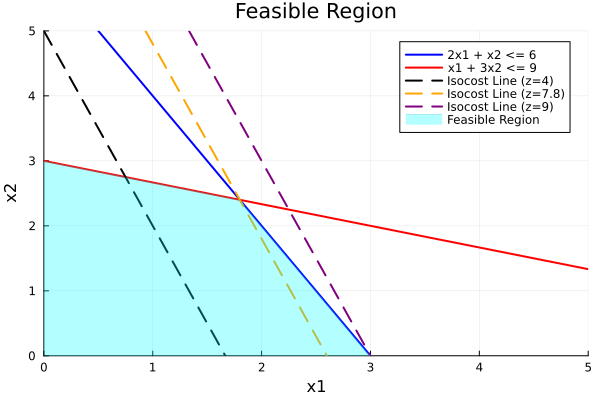

In [14]:
x1_range = 0:0.1:10
f1(x1) = 6 - 2*x1 
f2(x1) = 3 - (x1/3)

plot(x1_range, f1.(x1_range), label="2x1 + x2 <= 6", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="x1 + 3x2 <= 9", lw=2, color=:red)

# isocost lines
isocost_line(z, x1) = z - 3*x1
z = 5
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=4)", linestyle=:dash, lw=2, color=:black)
z = 27/5 + f1(9/5) # 7.8
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=7.8)", linestyle=:dash, lw=2, color=:orange)
z = 9
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=9)", linestyle=:dash, lw=2, color=:purple)

# feasiable region
x_vals = [0, 3, 9/5, 0]
y_vals = [0, 0, f1(9/5), 3]

plot!(x_vals, y_vals, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

xlabel!("x1")
ylabel!("x2")

title!("Feasible Region")

xlims!(0, 5)
ylims!(0, 5)


**The LP has a unique optimal solution**  
Optimal value: 9  
Descision Variable Values: (3, 0)

##### Question 3-2

The extreme points are (0,0), (0,3), (9/5,2.4) and (3,0)  
This problem has 0 rays because it is lower bounded by zero and the constraints are upper bounds i.e $\leq$

##### Question 3-3

$$ Ax = b $$
$$
A = \begin{bmatrix}
  0 & 0 & \frac{9}{5} & 3 \\
  0 & 3 & 2.4 & 0
\end{bmatrix}
$$
$$
x =
\begin{bmatrix}
  \lambda_1 \\
  \lambda_2 \\
  \lambda_3 \\
  \lambda_4
\end{bmatrix}
$$

$$
b =
\begin{bmatrix}
  1 \\
  1
\end{bmatrix}
$$

##### Math:
Because it is a convex combination there are rules:  
$$ \lambda_1 + \lambda_2 + \lambda_3 + \lambda_4 = 1 $$
$$ \lambda_i \geq 0 $$
So the system of equations becomes:

$$ \frac{9}{5}\lambda_3 + 3\lambda_4 = 1 $$
$$ 3\lambda_2 + 2.4\lambda_3 = 1 $$
$$ \lambda_1 + \lambda_2 + \lambda_3 + \lambda_4 = 1 $$

$$
\begin{bmatrix}
  0 & 0 & \frac{9}{5} & 3 \\
  0 & 3 & 2.4 & 0 \\ 
  1 & 1 & 1& 1
\end{bmatrix}
\begin{bmatrix}
  \lambda_1 \\
  \lambda_2 \\
  \lambda_3 \\
  \lambda_4
\end{bmatrix}
= 
\begin{bmatrix}
  1 \\
  1 \\
  1
\end{bmatrix}
$$


In [15]:
A = [0 0 9/5 3; 0 3 2.4 0; 1 1 1 1]
b = [1; 1; 1]
x = A \ b
println("x = ", x)
println(sum(x))


x = [0.39506172839506176, 0.20987654320987656, 0.15432098765432098, 0.24074074074074064]
1.0


##### Question 3-4

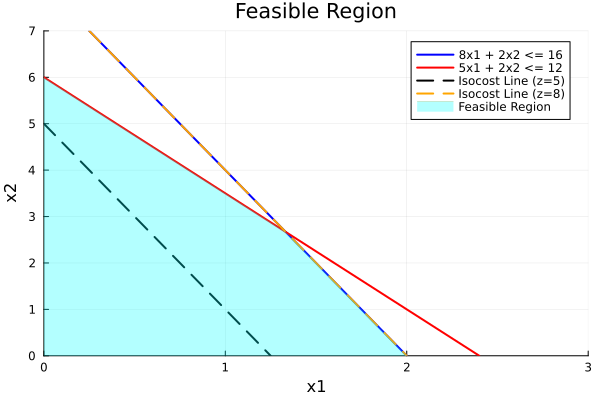

In [16]:
x1_range = 0:0.1:10
f1(x1) = 8 - 4*x1 
f2(x1) = 6 - ((5*x1)/2)

plot(x1_range, f1.(x1_range), label="8x1 + 2x2 <= 16", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="5x1 + 2x2 <= 12", lw=2, color=:red)

# isocost lines
isocost_line(z, x1) = z - 4*x1  # Pass z as a parameter to the function
z = 5
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=5)", linestyle=:dash, lw=2, color=:black)
z = 8
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=8)", linestyle=:dash, lw=2, color=:orange)

# feasiable region
x_vals = [0, 0, 4/3, 2]
y_vals = [0, 6, f1(4/3), 0]

plot!(x_vals, y_vals, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

xlabel!("x1")
ylabel!("x2")

title!("Feasible Region")

xlims!(0, 3)
ylims!(0, 7)

The LP has alternative or multiple optimal solutions: Two or more extreme points are optimal,
and the LP will have an infinite number of optimal solutions  


$$ x_1 = 2 - \frac{2}{3}\lambda $$
$$ x_2 = \frac{8}{3}\lambda $$
$$  0 \leq \lambda \leq 1 $$
$$ \{x | x = \lambda y + (1-\lambda)z,\space 0 \leq \lambda \leq 1 \}$$
$$ y = (2,0) \quad z = (\frac{4}{3}, \frac{8}{3}) $$

##### Questoin 3-5

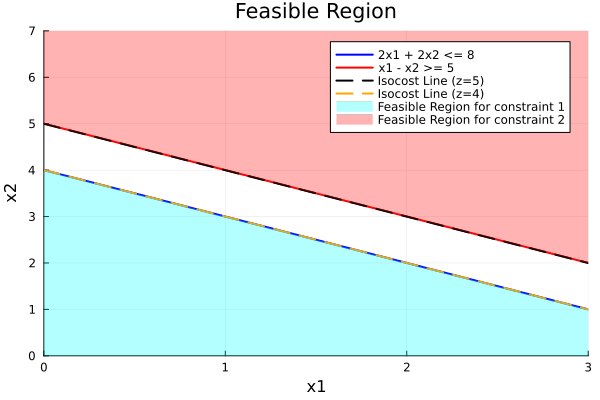

In [17]:
x1_range = 0:0.1:10
f1(x1) = 4 - x1 
f2(x1) = 5 - x1

plot(x1_range, f1.(x1_range), label="2x1 + 2x2 <= 8", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="x1 - x2 >= 5", lw=2, color=:red)

# isocost lines
isocost_line(z, x1) = z - x1  # Pass z as a parameter to the function
z = 5
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=5)", linestyle=:dash, lw=2, color=:black)
z = 4
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=4)", linestyle=:dash, lw=2, color=:orange)

# feasiable region
x_vals1 = [0, 0, 3, 3]
y_vals1 = [0, 4, 1, 0]

plot!(x_vals1, y_vals1, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region for constraint 1")

x_vals2 = [0, 0, 3, 3, 0]
y_vals2 = [5, 7, 7, 2, 5]

plot!(x_vals2, y_vals2, fill=(0, :red, 0.3), lw=0, label="Feasible Region for constraint 2")
xlabel!("x1")
ylabel!("x2")

title!("Feasible Region")

xlims!(0, 3)
ylims!(0, 7)


The LP is infeasible: The feasible region contains no points.

##### Question 3-6

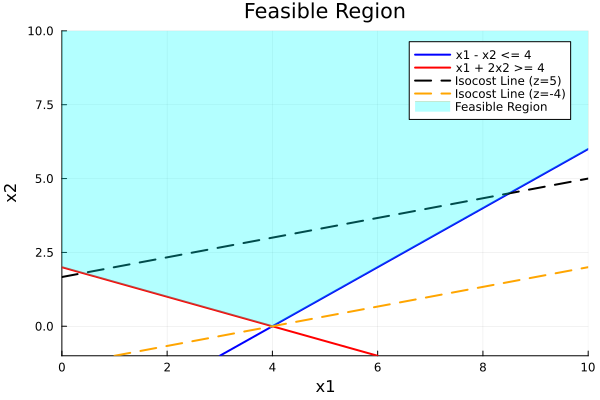

In [18]:
x1_range = 0:0.1:10
f1(x1) = -4 + x1 
f2(x1) = 2 - (x1/2)

plot(x1_range, f1.(x1_range), label="x1 - x2 <= 4", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="x1 + 2x2 >= 4", lw=2, color=:red)

# isocost lines
isocost_line(z, x1) = z/3 + x1/3  # Pass z as a parameter to the function
z = 5
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=5)", linestyle=:dash, lw=2, color=:black)
z = -4
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=-4)", linestyle=:dash, lw=2, color=:orange)

x_vals1 = [0, 0, 10, 10, 4, 0]
y_vals1 = [2, 10, 10, 6, 0, 2]

plot!(x_vals1, y_vals1, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

xlabel!("x1")
ylabel!("x2")

title!("Feasible Region")

xlims!(0, 10)
ylims!(-1, 10)


**Max Problem**  
The LP is unbounded: There are points in the feasible region with arbitrarily large z-values (max
problem) or arbitrarily small z-values (min problem)

##### Question 3-7

Extreme Points: $(0, 2), (4, 0)$  

Extreme Rays: $x_1(t) = (4,0) + t(1,1)$ and $x_2(t) = (0,2) + t(0,1)$ for $t \geq 0$

##### Question 3-8

$$ Ax = b $$
$$
A = \begin{bmatrix}
  0 & 4 & 1 & 0 \\
  2 & 0 & 1 & 1
\end{bmatrix}
$$
$$
x =
\begin{bmatrix}
  \lambda_1 \\
  \mu_1 \\
  \lambda_2 \\
  \mu_2 \\
\end{bmatrix}
$$

$$
\hat{x} =
\begin{bmatrix}
  8 \\
  6
\end{bmatrix}
$$
$$
\mu_i \geq 0, \quad \lambda_1 + \lambda_2 = 1
$$

In [19]:
m = Model(HiGHS.Optimizer)

@variable(m, λ₁ >= 0)
@variable(m, λ₂ >= 0)
@variable(m, μ₁ >= 0)
@variable(m, μ₂ >= 0)

@constraint(m, 0 * λ₁ + 4 * λ₂ + 1 * μ₁ + 0 * μ₂ == 8)
@constraint(m, 2 * λ₁ + 0 * λ₂ + 1 * μ₁ + 1 * μ₂ == 6) 
@constraint(m, λ₁ + λ₂ == 1)

set_silent(m)
optimize!(m)

println("Model Termination Status: ", termination_status(m))
println("λ₁ = ", value(λ₁))
println("λ₂ = ", value(λ₂))
println("μ₁ = ", value(μ₁))
println("μ₂ = ", value(μ₂))

Model Termination Status: OPTIMAL
λ₁ = 0.3333333333333333
λ₂ = 0.6666666666666667
μ₁ = 5.333333333333333
μ₂ = 0.0


##### Question 4-1

Decision Variables:  

$ x_{ij} $ : barrels of raw gas $i$ mixed to produce aviation gas $j$  
$ s_{i} $ : barrels of raw gas $i$ sold without being mixed  


Raw gasoline sold costs:

$$ 4.83\sum_{i \in I}s_{i} $$

Refined gasolines costs:

$$ \sum_{j \in J}P_j\sum_{i \in I}x_{ij} $$

where:  
- $P_j$: is the cost of each aviation gas barrel  
- $PN_i$: is the performance number for raw gas i
- $RVP_i$: is the vapor pressure for raw gas i
- $PN_j$: is the performance number for aviation gas j
- $RVP_j$: is the vapor pressure for aviation gas j
- $I = \{ \text{Alkylate, Catalytic-Cracked, Straight-Run, Isopentane} \}$
- $J = \{ \text{Avgas A, Avgas B} \}$


Then a linear program that will maximize profit will be: 

$$ \max \quad \sum_{j \in J}P_j\sum_{i \in I}x_{ij} + 4.83\sum_{i \in I}s_{i} $$

s.t.  
$$\sum_{j \in J} x_{ij} + s_i = \text{Available Barrels of } i, \quad \forall i \in I$$
$$\sum_{i \in I} PN_i x_{ij} \geq PN_j \sum_{i \in I} x_{ij} \quad \forall j \in J$$
$$\sum_{i \in I} RVP_i x_{ij} \leq RVP_j \sum_{i \in I} x_{ij} \quad \forall j \in J$$
$$x_{ij} \geq 0, \quad s_i \geq 0 \quad \forall i \in I, \forall j \in J$$



##### Question 4-2

In [20]:
m = Model(HiGHS.Optimizer)

gas_types = [:Alkylate, :CatalyticCracked, :StraightRun, :Isopentane]
avgas_types = [:AvgasA, :AvgasB]
PN = Dict(:Alkylate => 107, :CatalyticCracked => 93, :StraightRun => 87, :Isopentane => 108)
RVP = Dict(:Alkylate => 5, :CatalyticCracked => 8, :StraightRun => 4, :Isopentane => 21)
PN_min = Dict(:AvgasA => 100, :AvgasB => 91)
RVP_max = Dict(:AvgasA => 7, :AvgasB => 7)
availability = Dict(:Alkylate => 3814, :CatalyticCracked => 2666, :StraightRun => 4016, :Isopentane => 1300)
prices = Dict(:AvgasA => 6.45, :AvgasB => 5.91)
cost_per_raw_barrel = 4.83

@variable(m, x[gas_types, avgas_types] >= 0)
@variable(m, s[gas_types] >= 0)

@objective(m, Max, sum(prices[j] * sum(x[i, j] for i in gas_types) for j in avgas_types) + sum(cost_per_raw_barrel * s[i] for i in gas_types))

@constraint(m, balance[i in gas_types], sum(x[i, j] for j in avgas_types) + s[i] == availability[i])
@constraint(m, PN_constraints[j in avgas_types], sum(PN[i] * x[i, j] for i in gas_types) >= PN_min[j] * sum(x[i, j] for i in gas_types))
@constraint(m, RVP_constraints[j in avgas_types], sum(RVP[i] * x[i, j] for i in gas_types) <= RVP_max[j] * sum(x[i, j] for i in gas_types))

set_silent(m)
optimize!(m)

# Print results
println("Objective Value (Max Profit): ", objective_value(m))
println("Raw Gas Sold:")
for i in gas_types
    println("$i: ", value(s[i]))
end

println("Raw Gas Used in Aviation Gas:")
for i in gas_types, j in avgas_types
    println("$i to $j: ", value(x[i, j]))
end


Objective Value (Max Profit): 73879.38
Raw Gas Sold:
Alkylate: 0.0
CatalyticCracked: 0.0
StraightRun: 0.0
Isopentane: 85.0
Raw Gas Used in Aviation Gas:
Alkylate to AvgasA: 3754.0
Alkylate to AvgasB: 60.0
CatalyticCracked to AvgasA: 2666.0
CatalyticCracked to AvgasB: 0.0
StraightRun to AvgasA: 920.0
StraightRun to AvgasB: 3096.0
Isopentane to AvgasA: 543.0
Isopentane to AvgasB: 672.0


##### Question 5-1

Given:  

$$E: \text{Set of elements, } E = \{C, Cu, Mn\}$$
$$J: \text{Set of raw materials, } J = \{F, U, E, L, O, N, M\}  $$
$$c_j: \text{Cost per ton of material } j \in J  $$
$$u_j: \text{Maximum tons available of material } j \in J$$
$$\gamma_{ej}: \text{Percentage of element } e \in E \text{ in material } j \in J$$
$$\alpha_e: \text{Minimum percentage of element } e \in E \text{ required in the final product}$$
$$\beta_e: \text{Maximum percentage of element } e \in E \text{ required in the final product}$$
$$T: \text{total amount of tons of material needed}$$

Decision Variables: 

$ x_j $: number of tons of raw material j to add the the blend

Cost of materials:  

$$ \sum_{j \in J} c_j x_j $$

Then a linear program to minimize cost of material will be:  

$$ \min \quad \sum_{j \in J} c_j x_j $$

s.t.  

$$ x_j \leq u_j $$

$$ \sum_{j \in J}x_j = T $$

$$ \sum_{j \in J} \gamma_{ej} x_j \geq \alpha_e \sum_{j \in J}x_j \quad \forall e \in E$$

$$ \sum_{j \in J} \gamma_{ej} x_j \leq \beta_e \sum_{j \in J}x_j \quad \forall e \in E$$

$$ x_j \geq 0, \quad \forall j \in J$$


In [21]:
m = Model(HiGHS.Optimizer)

E = [:C, :Cu, :Mn]
J = [:F, :U, :E, :L, :O, :N, :M] 
c_j = Dict(:F => 200, :U => 250, :E => 150, :L => 220, :O => 240, :N => 200, :M => 165)
u_j = Dict(:F => 400, :U => 300, :E => 600, :L => 500, :O => 200, :N => 300, :M => 250)
gamma_ej = Dict(
    (:C, :F) => 0.025,  (:Cu, :F) => 0.0,       (:Mn, :F) => 0.013,
    (:C, :U) => 0.03,   (:Cu, :U) => 0.003,     (:Mn, :U) => 0.018,
    (:C, :E) => 0.015,  (:Cu, :E) => 0.005,     (:Mn, :E) => 0.015,
    (:C, :L) => 0.0,    (:Cu, :L) => 0.009,     (:Mn, :L) => 0.0,
    (:C, :O) => 0.004,  (:Cu, :O) => 0.009,     (:Mn, :O) => 0.011,
    (:C, :N) => 0.0,    (:Cu, :N) => 0.004,     (:Mn, :N) => 0.012,
    (:C, :M) => 0.0,    (:Cu, :M) => 0.006,     (:Mn, :M) => 0.0
)
alpha_e = Dict(:C => 0.02, :Cu => 0.004, :Mn => 0.012)
beta_e = Dict(:C => 0.03, :Cu => 0.006, :Mn => 0.0165)
T = 500

@variable(m, x[J] >= 0)

@objective(m, Min, sum(c_j[j] * x[j] for j in J))

@constraint(m, [j in J], x[j] <= u_j[j])
@constraint(m, sum(x[j] for j in J) == 500)
@constraint(m, [e in E], sum(gamma_ej[(e,j)] * x[j] for j in J) >= alpha_e[e] * sum(x[j] for j in J))
@constraint(m, [e in E], sum(gamma_ej[(e,j)] * x[j] for j in J) <= beta_e[e] * sum(x[j] for j in J))

set_silent(m)
optimize!(m)

# Print results
println("Termination status: ", termination_status(m))
println("Objective Value (Min Cost): ", objective_value(m))
println("Optimal values of decision variables (tons):")
for j in J
    println("$j = ", value(x[j]))
end


Termination status: OPTIMAL
Objective Value (Min Cost): 90909.09090909091
Optimal values of decision variables (tons):
F = 45.454545454545446
U = 136.36363636363637
E = 318.1818181818182
L = 0.0
O = 0.0
N = 0.0
M = 0.0


Given:  

$$I: \text{Set of Orders}$$
$$\ell_i: \text{minimun delivery quantity in tons}$$
$$u_i: \text{maximum delivery quantity in tons}$$
$$r_i: \text{cost per ton of material sold}$$
$$E: \text{Set of elements, } E = \{C, Cu, Mn\}$$
$$J: \text{Set of raw materials, } J = \{F, U, E, L, O, N, M\}  $$
$$d_j: \text{Cost per ton of material bought } j \in J  $$
$$u_j: \text{Maximum tons available of material } j \in J$$
$$\gamma_{ej}: \text{Percentage of element } e \in E \text{ in material } j \in J$$
$$\alpha_{ei}: \text{Minimum percentage of element } e \in E \text{ required in the final product}$$
$$\beta_{ei}: \text{Maximum percentage of element } e \in E \text{ required in the final product}$$
$$T: \text{total amount of tons of material needed}$$

Decision Variables: 

$ x_{ij} $: number of tons of raw material j used to fulfill order i

Cost of materials:  

$$ \sum_{j \in J} d_j  \sum_{i \in I}x_{ij} $$

Profit from order:  

$$ \sum_{i \in I} r_i \sum_{j \in J} x_{ij} $$

Then a linear program to maximize profit will be:  

$$ \max \quad \sum_{i \in I} r_i \sum_{j \in J} x_{ij} - \sum_{j \in J} d_j  \sum_{i \in I}x_{ij} $$

s.t.  

$$ \sum_{j \in J}x_{ij} \geq \ell_i \quad \forall i \in I$$

$$ \sum_{j \in J}x_{ij} \leq u_i \quad \forall i \in I$$

$$ \sum_{j \in J} \gamma_{ej} x_{ij} \leq \beta_{ei} \sum_{j \in J} x_{ij} \quad \forall e \in E, \forall i \in I$$

$$ \sum_{j \in J} \gamma_{ej} x_{ij} \geq \alpha_{ei} \sum_{j \in J} x_{ij} \quad \forall e \in E, \forall i \in I$$

$$ x_{ij} \geq 0, \quad \forall j \in J, \quad \forall i \in I$$


In [22]:
# Read the data from Excel and setup data structures
# First sheet: 

table = XLSX.readtable("alloy-blending.xlsx", "raw_data"; infer_eltypes=true)
df = DataFrame(table)

J = df.Raw 

# Get the cost of each raw
d = Dict(zip(J,df.Cost))

table = XLSX.readtable("alloy-blending.xlsx", "order_data"; infer_eltypes=true)
df = DataFrame(table)

I = df.Order 

# Now make dictionary for revenue lower and upper
r = Dict(zip(I,df.Revenue))
l = Dict(zip(I,df.Lower))
u = Dict(zip(I,df.Upper))

# Get the elements
table = XLSX.readtable("alloy-blending.xlsx", "element_data"; infer_eltypes=true)
df = DataFrame(table)
E = df.Element

# We'll make NamedArrays for the rest.  First initialize them all with zeros 
ei_zero = zeros(length(E), length(I))
α = NamedArray(ei_zero, (E,I), ("Element","Order"))
ei_zero2 = zeros(length(E), length(I))
β = NamedArray(ei_zero2, (E,I), ("Element","Order"))

table = XLSX.readtable("alloy-blending.xlsx", "element_order_data"; infer_eltypes=true)
df = DataFrame(table)
for row in eachrow(df)
    α[row.Element,row.Order] = row.Alpha 
    β[row.Element,row.Order] = row.Beta 
end 


ej_zero = zeros(length(E), length(J))
γ = NamedArray(ej_zero, (E,J), ("Element","Raw"))

table = XLSX.readtable("alloy-blending.xlsx", "element_raw_data"; infer_eltypes=true)
df = DataFrame(table)
for row in eachrow(df)
    γ[row.Element,row.Raw] = row.Gamma 
end 


In [23]:
m = Model(HiGHS.Optimizer)

@variable(m, x[I, J] >= 0)

@objective(m, Max, sum(r[i] * sum(x[i, j] for j in J) for i in I) - sum(d[j] * sum(x[i, j] for i in I) for j in J))

@constraint(m, [i in I], sum(x[i, j] for j in J) >= l[i]) # lower bound materail usage
@constraint(m, [i in I], sum(x[i, j] for j in J) <= u[i]) # upper bound materail usage
@constraint(m, [e in E, i in I], sum(γ[e,j] * x[i, j] for j in J) >= α[e, i] * sum(x[i, j] for j in J))
@constraint(m, [e in E, i in I], sum(γ[e,j] * x[i, j] for j in J) <= β[e, i] * sum(x[i, j] for j in J))

set_silent(m)
optimize!(m)

# Print results
println("Termination status: ", termination_status(m))
println("Objective Value (Max Profit): ", objective_value(m))
# println("Optimal values of decision variables:")
# for j in J
#     for i in I
#         println("Order $i: $j = ", value(x[i, j]))
#     end 
# end


Termination status: OPTIMAL
Objective Value (Max Profit): 1239.302018858615
